# Equation of State Calculation

In [3]:
import jax.numpy as jnp
from jax import random, jit
from matplotlib import pyplot as plt
import numpy as np
from jax_md import space, energy, simulate, quantity
from tqdm.notebook import tqdm

In [8]:
# Simulation parameters
num_steps = 20000
num_steps_equilibrium = 2000
dt = 1e-3
sigma = 1.0
epsilon = 1.0
Nx = 10
dim = 3
num_particles = Nx**dim

## 3d LJ fluid in periodic box 

In [9]:
# Function to compute average pressure for given kT and spacing
def compute_avg_pressure(kT, spacing):
    side_length = Nx * spacing
    density = 1 / spacing**dim
    displacement, shift = space.periodic(side_length)
    energy_fn = energy.lennard_jones_pair(displacement, sigma=sigma, epsilon=epsilon, r_cutoff=2.5 * sigma)
    energy_fn = jit(energy_fn)
    
    init_fn, apply_fn = simulate.nvt_nose_hoover(energy_fn, shift, dt=dt, kT=kT)
    apply_fn = jit(apply_fn)
    
    key = random.PRNGKey(0)
    base_R = np.stack([np.array(r) for r in np.ndindex((Nx,)*dim)]) * spacing
    max_offset = (spacing - sigma) / 2
    random_offset = np.random.uniform(-max_offset, max_offset, size=(num_particles, dim))
    R = jnp.array(base_R + random_offset)
    state = init_fn(key, R)
    
    pressures = jnp.zeros(num_steps_equilibrium)
    
    for t in tqdm(range(num_steps)):
        state = apply_fn(state)
        if t >= (num_steps - num_steps_equilibrium):
            pressure_t = quantity.pressure(energy_fn, state.position, box=side_length, kT=kT)
            pressures = pressures.at[t - (num_steps - num_steps_equilibrium)].set(pressure_t)
    
    return jnp.mean(pressures)


In [10]:
## Compare to results in J. Phys. Chem. 1996, 100, 43, 17365–17372

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

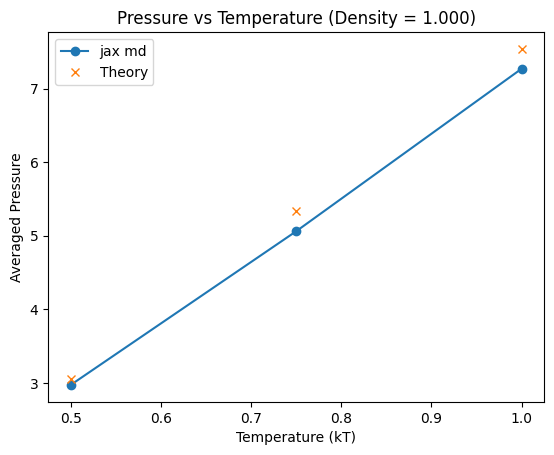

In [11]:
# Vary temperature (kT)
kT_values = jnp.array([0.5, 0.75, 1.0])  
spacing_fixed = 1 * sigma
density_fixed = 1 / spacing_fixed**dim
pressures_vs_kT = jnp.array([compute_avg_pressure(kT, spacing=spacing_fixed) for kT in kT_values])


plt.figure()
plt.plot(kT_values, pressures_vs_kT, 'o-',label='jax md')
plt.plot(kT_values,[3.057,5.332,7.539],'x',label='Theory')
plt.xlabel('Temperature (kT)')
plt.ylabel('Averaged Pressure')
plt.title(f'Pressure vs Temperature (Density = {density_fixed:.3f})')
plt.legend()
plt.show()


  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

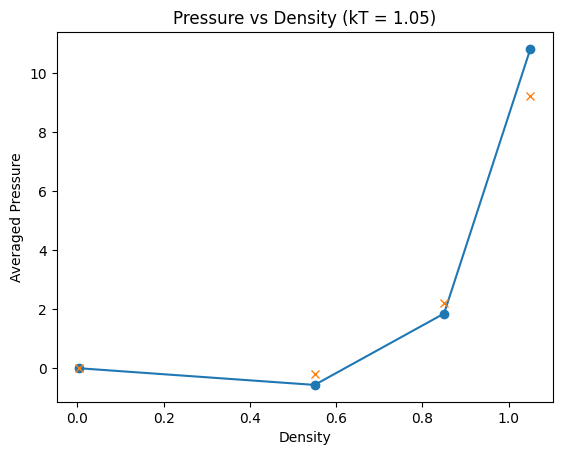

In [ ]:
# Vary spacing to change density
density_values = jnp.linspace(0.005,1.05,10)
spacing_values=1/density_values**(1/3)
kT_fixed = 1.05
pressures_vs_density = jnp.array([compute_avg_pressure(kT=kT_fixed, spacing=s) for s in spacing_values])


plt.figure()
plt.plot(density_values, pressures_vs_density, 'o-',label='jax md')
plt.plot([0.005,0.55,0.85,1.05],[0.005,-0.206,2.217,9.213],'x',label='Theory')
plt.xlabel('Density')
plt.ylabel('Averaged Pressure')
plt.title(f'Pressure vs Density (kT = {kT_fixed})')
plt.show()


In [1]:
def LJ_EOS_pressure(rho,kT):
    a=0.675
    b=1.0
    c=0.562
    d=0.0
    rho_c=0.31
    return rho*kT*((1+b*rho+c*rho**2+d*rho**3)/(1-rho/rho_c)-a*rho**2)

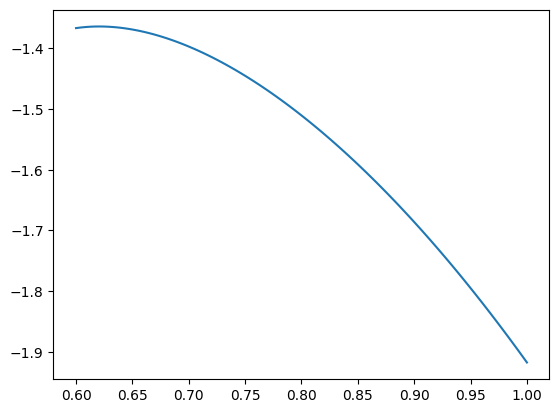

In [6]:
rhos=jnp.linspace(0.6,1,100)
plt.plot(rhos,LJ_EOS_pressure(rhos,1.05))
plt.show()